In [107]:
import pandas as pd

In [108]:
df=pd.read_csv("placement (2).csv")

In [109]:
df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


In [110]:
# seperating input and output variables
x=df[["cgpa"]]
y=df[["package"]]

In [111]:
x

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94
...,...
195,6.93
196,5.89
197,7.21
198,7.63


In [112]:
y

,package
0,3.26
1,1.98
2,3.25
3,3.67
4,3.57
...,...
195,2.46
196,2.57
197,3.24
198,3.96


In [113]:
# train test split
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [114]:
x_train

,cgpa
42,5.95
191,7.28
15,7.25
193,4.57
151,6.12
...,...
100,7.95
71,7.47
127,6.78
54,6.86


In [115]:
y_train

,package
42,2.54
191,3.48
15,3.23
193,1.94
151,2.76
...,...
100,4.14
71,3.34
127,3.11
54,3.09


In [116]:
# training

from sklearn.linear_model import LinearRegression

model=LinearRegression()
model.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[0.58]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['cgpa']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[-1.03]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [117]:
# prediction

y_predicted=model.predict(x_test)

In [118]:
# accuracy score
from sklearn.metrics import r2_score
r2_score(y_test,y_predicted)

0.7407326960279441

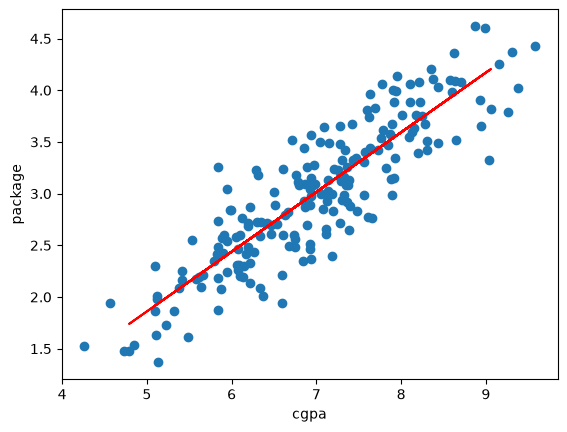

In [119]:
import matplotlib.pyplot as plt

plt.scatter(x=df["cgpa"],y=df["package"])
plt.xlabel("cgpa")
plt.ylabel("package")
plt.plot(x_test,model.predict(x_test),color="red")

In [120]:
# slope and y intercept of line

m=model.coef_
c=model.intercept_

In [121]:
m

array([[0.57758287]])

In [122]:
c

array([-1.02724124])

My LR Model

In [123]:
class MyLrModel:
    def __init__(self):
        self.m=None
        self.c=None

    def fit(self, x_train, y_train):
        num=0
        den=0
        for i in range (x_train.shape[0]):
            num=num + (x_train[i]-x_train.mean())*(y_train[i]-y_train.mean())
            den=den+ pow((x_train[i]-x_train.mean()),2)
        
        self.m=num/den
        self.c=y.mean()-self.m*x_train.mean()
 
    def predict(self, x_test):
        return self.m*x_test+self.c

In [124]:
import pandas as pd
df=pd.read_csv("placement (2).csv")

In [125]:
df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


In [126]:
# seperate input and output variable

x=df[["cgpa"]].values
y=df[["package"]].values

In [127]:
# train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [128]:
# My LR model

myModel=MyLrModel()
myModel.fit(x_train,y_train)

In [129]:
# predicting values

myModel.predict(x_test)

array([[2.46400942],
       [1.9763873 ],
       [3.0973577 ],
       [4.08381166],
       [3.76993994],
       [3.56816527],
       [1.67372529],
       [3.46167308],
       [3.19824504],
       [3.52332645],
       [3.19264018],
       [3.6466332 ],
       [2.53126765],
       [3.34957604],
       [2.87316362],
       [2.85634906],
       [2.66578409],
       [4.11744077],
       [1.79703203],
       [3.94929521],
       [3.93248065],
       [3.56256042],
       [3.38320515],
       [4.19030384],
       [3.52893131],
       [3.71389142],
       [2.64336469],
       [3.19264018],
       [3.35518089],
       [3.68026231],
       [2.99647036],
       [3.11417226],
       [3.15340622],
       [2.71062291],
       [3.00207522],
       [2.4079609 ],
       [3.22066444],
       [2.99647036],
       [2.91239758],
       [3.21505959]])